In [1]:
library(data.table)
library(dplyr)
library(ggplot2)
library(qvalue)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
pb_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/review_files/all_celltypes_pseudobulk/results/'
# pb_file = paste0(pb_dir,'summary_stats_all_celltypes_all_cis_cv_gene_level_results_1000000bp.tsv')
pb_file = paste0(pb_dir,'summary_stats_all_celltypes_all_cis_cv_gene_level_results_100000bp.tsv')

In [3]:
pb_df = as.data.frame(fread(pb_file))

In [4]:
nrow(pb_df)
head(pb_df)

[1] 21192

,gene,ACAT_p,top_MarkerID,top_pval
,<chr>,<dbl>,<chr>,<dbl>
1,ENSG00000000457,4.960838e-04,1:169788227:C:T,3.78384e-06
2,ENSG00000000460,1.864119e-03,1:169938856:C:A,1.99800e-05
3,ENSG00000000938,5.858392e-02,1:27638592:C:CT,3.10999e-04
4,ENSG00000000971,2.461204e-01,1:196692901:C:T,1.62443e-03
5,ENSG00000001460,7.775551e-06,1:24426294:CT:C,1.46893e-07
6,ENSG00000001461,6.519180e-01,1:24345043:C:CCTCCACACCTGTGCCCCCTCCACACCTGTGCA,2.70544e-03


In [5]:
pb_df$qv = qvalue(pb_df$ACAT_p)$qvalues
pb_df = pb_df %>% mutate(significant = ifelse(qv < 0.05, 1, 0))
head(pb_df)
nrow(pb_df[pb_df$qv < 0.05,])
pb_sign_genes = unique(pb_df[pb_df$qv < 0.05,]$gene)
length(pb_sign_genes)

,gene,ACAT_p,top_MarkerID,top_pval,qv,significant
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,ENSG00000000457,4.960838e-04,1:169788227:C:T,3.78384e-06,1.120387e-03,1
2,ENSG00000000460,1.864119e-03,1:169938856:C:A,1.99800e-05,3.811685e-03,1
3,ENSG00000000938,5.858392e-02,1:27638592:C:CT,3.10999e-04,8.509346e-02,0
4,ENSG00000000971,2.461204e-01,1:196692901:C:T,1.62443e-03,3.023816e-01,0
5,ENSG00000001460,7.775551e-06,1:24426294:CT:C,1.46893e-07,2.215836e-05,1
6,ENSG00000001461,6.519180e-01,1:24345043:C:CCTCCACACCTGTGCCCCCTCCACACCTGTGCA,2.70544e-03,6.989293e-01,0


[1] 11359

[1] 11359

In [6]:
ss_100kb = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/'
celltypes = list.files(ss_100kb)
celltypes = celltypes[!(celltypes %in% c('annotate','coloc_results','README.md','CD4_TCM_sample_perm0'))]
length(celltypes)
celltypes

[1] 28

[1] "ASDC"              "B_intermediate"    "B_memory"         
 [4] "B_naive"           "CD14_Mono"         "CD16_Mono"        
 [7] "CD4_CTL"           "CD4_Naive"         "CD4_Proliferating"
[10] "CD4_TCM"           "CD4_TEM"           "CD8_Naive"        
[13] "CD8_Proliferating" "CD8_TCM"           "CD8_TEM"          
[16] "cDC1"              "cDC2"              "dnT"              
[19] "gdT"               "HSPC"              "ILC"              
[22] "MAIT"              "NK"                "NK_CD56bright"    
[25] "NK_Proliferating"  "pDC"               "Plasmablast"      
[28] "Treg"

In [7]:
df_list = list()
for (celltype in celltypes){
    myfile = paste0(ss_100kb,celltype,'/',celltype,'_all_cis_cv_gene_level_results.tsv')
    df_ct = fread(myfile)
    df_curr = df_ct[df_ct$gene %in% pb_df$gene,]
    if (nrow(df_curr)==0){next}
    df_curr$qv = qvalue(df_curr$ACAT_p)$qvalues
    df_curr = df_curr %>% mutate(significant = ifelse(qv < 0.05, 1, 0))
    df_curr$celltype = celltype
    df_list[[celltype]] = df_curr
}
df_pb_genes = as.data.frame(rbindlist(df_list))

In [8]:
head(df_pb_genes)

,gene,ACAT_p,top_MarkerID,top_pval,qv,significant,celltype
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,ENSG00000000457,0.2842556,1:169927679:G:GT,0.001991190,0.8117725,0,ASDC
2,ENSG00000000460,0.9486428,1:169788459:T:C,0.003823260,0.9977706,0,ASDC
3,ENSG00000000938,0.6203965,1:27697371:C:A,0.003466500,0.9977706,0,ASDC
4,ENSG00000001460,0.8674904,1:24322926:C:T,0.000183998,0.9977706,0,ASDC
5,ENSG00000001461,0.9658630,1:24374254:TTTG:T,0.006238500,0.9977706,0,ASDC
6,ENSG00000004455,0.9117075,1:32976533:A:ACACAC,0.004864050,0.9977706,0,ASDC


In [9]:
length(unique(df_pb_genes$gene))

[1] 21192

In [10]:
pb_df$celltype = 'all_celltypes'
df_combine = rbind(df_pb_genes, pb_df)

In [11]:
df_to_plot = as.data.frame(table(df_combine$celltype, df_combine$significant))
colnames(df_to_plot) = c('celltype','significant','n')

In [12]:
df_to_plot <- df_to_plot %>% mutate(highlight = ifelse(celltype == "all_celltypes", TRUE, FALSE))

In [13]:
head(df_to_plot)

,celltype,significant,n,highlight
,<fct>,<fct>,<int>,<lgl>
1,all_celltypes,0,9833,TRUE
2,ASDC,0,15170,FALSE
3,B_intermediate,0,6434,FALSE
4,B_memory,0,6755,FALSE
5,B_naive,0,4128,FALSE
6,CD14_Mono,0,5061,FALSE


In [14]:
# Create a new variable for ordering based on significant == 1
order_levels <- df_to_plot %>%
  filter(significant == 1) %>%
  arrange(desc(n)) %>%
  pull(celltype)

# Set as factor with levels in desired order
df_to_plot$celltype <- factor(df_to_plot$celltype, levels = order_levels)

In [15]:
head(df_to_plot)

,celltype,significant,n,highlight
,<fct>,<fct>,<int>,<lgl>
1,all_celltypes,0,9833,TRUE
2,ASDC,0,15170,FALSE
3,B_intermediate,0,6434,FALSE
4,B_memory,0,6755,FALSE
5,B_naive,0,4128,FALSE
6,CD14_Mono,0,5061,FALSE


In [16]:
table(df_to_plot$highlight, useNA = "ifany")


FALSE  TRUE 
   56     2 

Warning message:
“Using alpha for a discrete variable is not advised.”


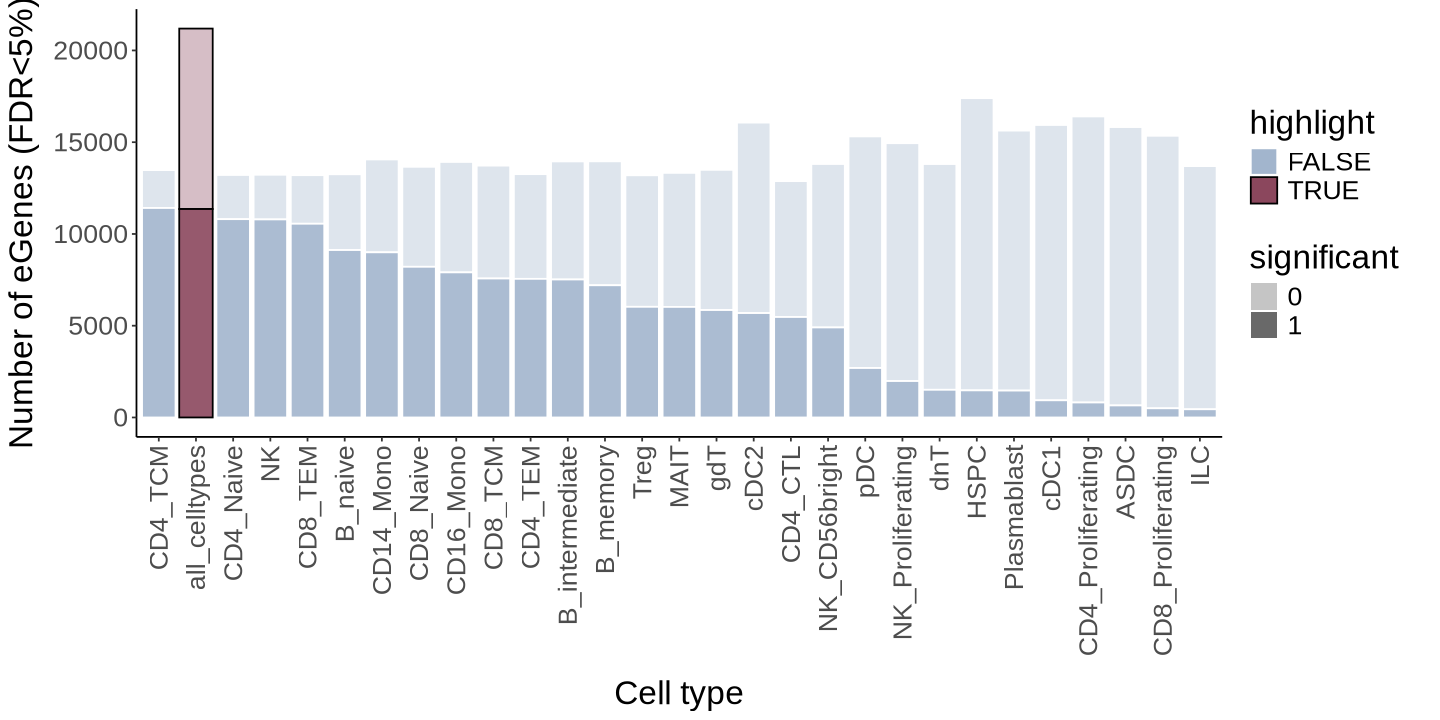

In [17]:
options(repr.plot.width = 12, repr.plot.height = 6)
p = ggplot(df_to_plot, aes(x=celltype, y=n, alpha=significant)) 
p = p + geom_bar(stat='identity', aes(colour=highlight,fill=highlight)) 
p = p + scale_color_manual(values = c("TRUE" = "black", "FALSE" = "white"))
p = p + scale_fill_manual(values = c("TRUE" = 'palevioletred4',"FALSE" = 'lightsteelblue3'))
p = p + scale_alpha_discrete(range = c(0.35, 0.9))
p = p + theme_classic() 
p = p + theme(text = element_text(size=20), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
p = p + ylab('Number of eGenes (FDR<5%)') + xlab('Cell type')
p

Warning message:
“Using alpha for a discrete variable is not advised.”


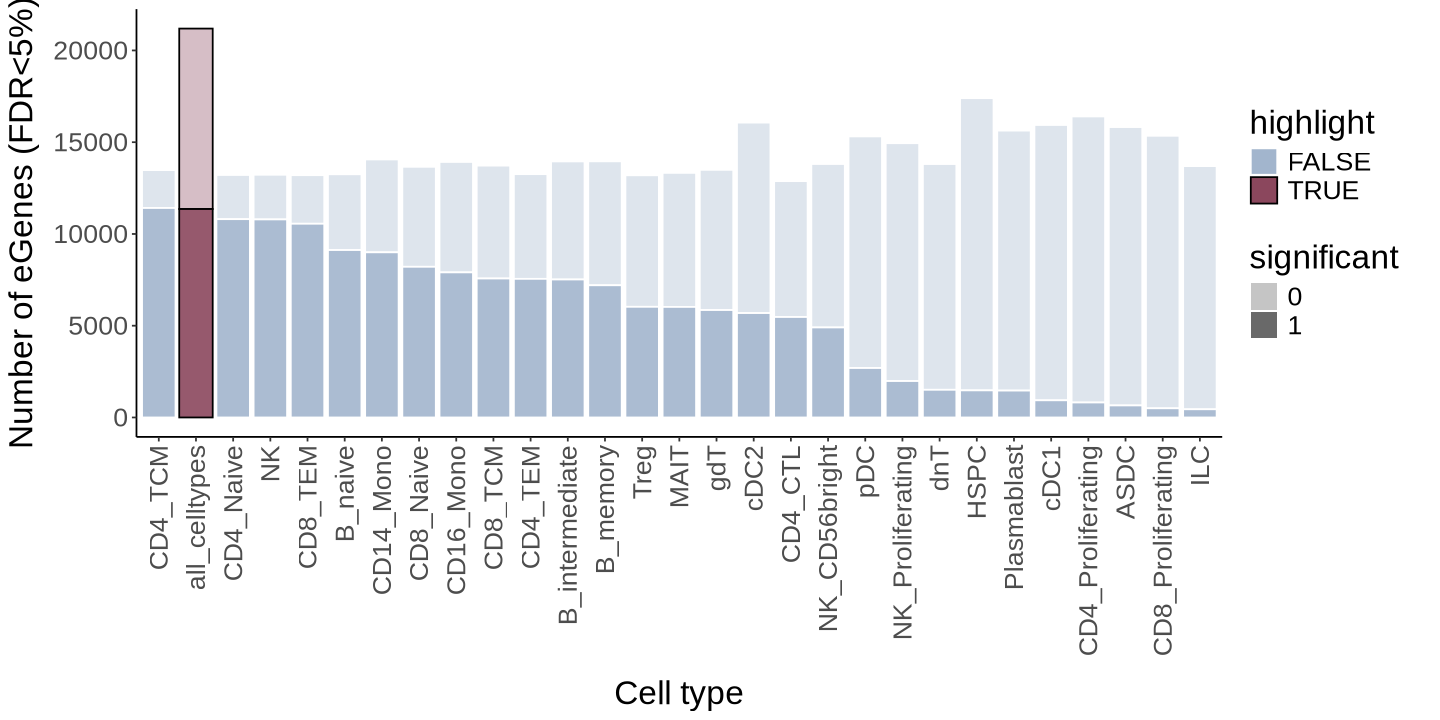

In [18]:
options(repr.plot.width = 12, repr.plot.height = 6)
p = ggplot(df_to_plot, aes(x=celltype, y=n, alpha=significant)) 
p = p + geom_bar(stat='identity', aes(colour=highlight,fill=highlight)) 
p = p + scale_color_manual(values = c("TRUE" = "black", "FALSE" = "white"))
p = p + scale_fill_manual(values = c("TRUE" = 'palevioletred4',"FALSE" = 'lightsteelblue3'))
p = p + scale_alpha_discrete(range = c(0.35, 0.9))
p = p + theme_classic() 
p = p + theme(text = element_text(size=20), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
p = p + ylab('Number of eGenes (FDR<5%)') + xlab('Cell type')
p

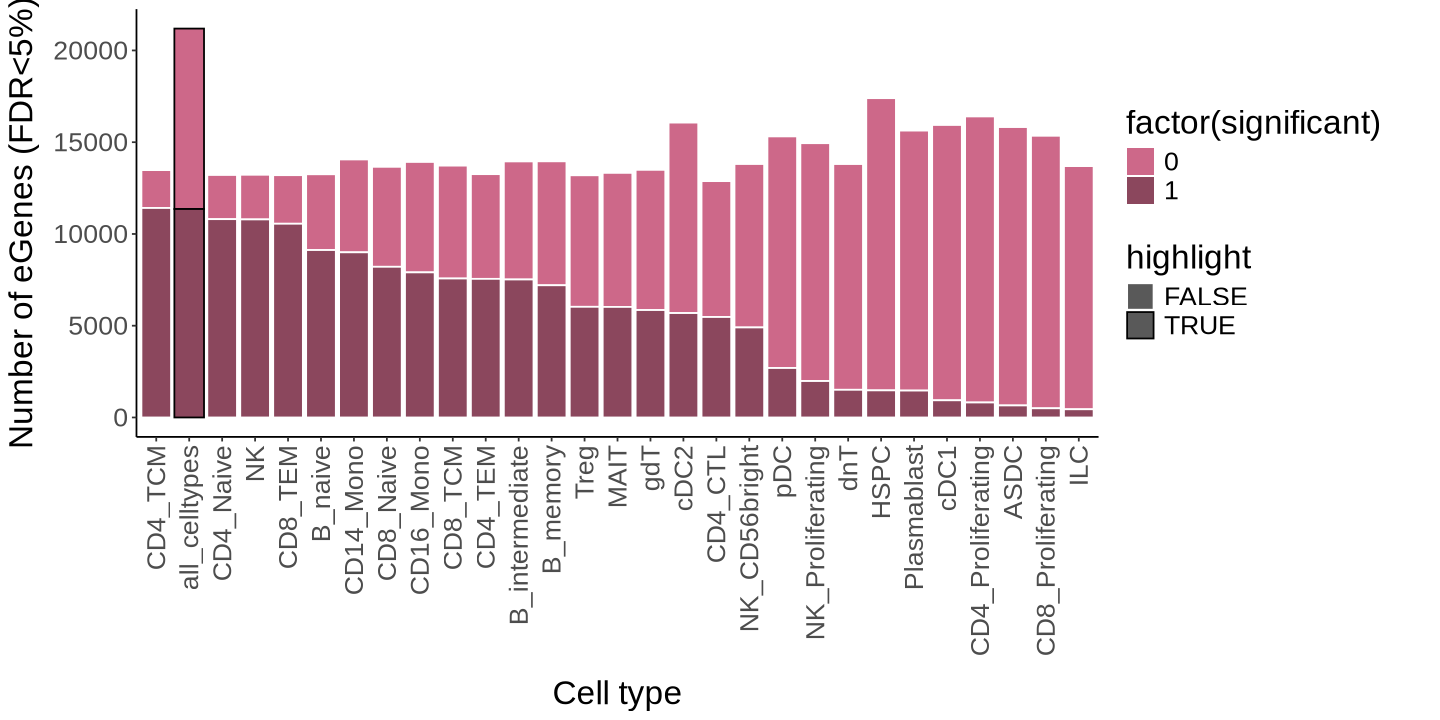

In [19]:
options(repr.plot.width = 12, repr.plot.height = 6)
p = ggplot(df_to_plot, aes(x=celltype, y=n, fill=factor(significant))) #+ geom_bar(stat='identity')
p = p + geom_bar(stat='identity', aes(color = highlight)) 
p = p + scale_color_manual(values = c("TRUE" = "black", "FALSE" = "white")) 
p = p + scale_fill_manual(values = c('palevioletred3','palevioletred4'))
p = p + theme_classic() 
p = p + theme(text = element_text(size=20), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
p = p + ylab('Number of eGenes (FDR<5%)') + xlab('Cell type')
p

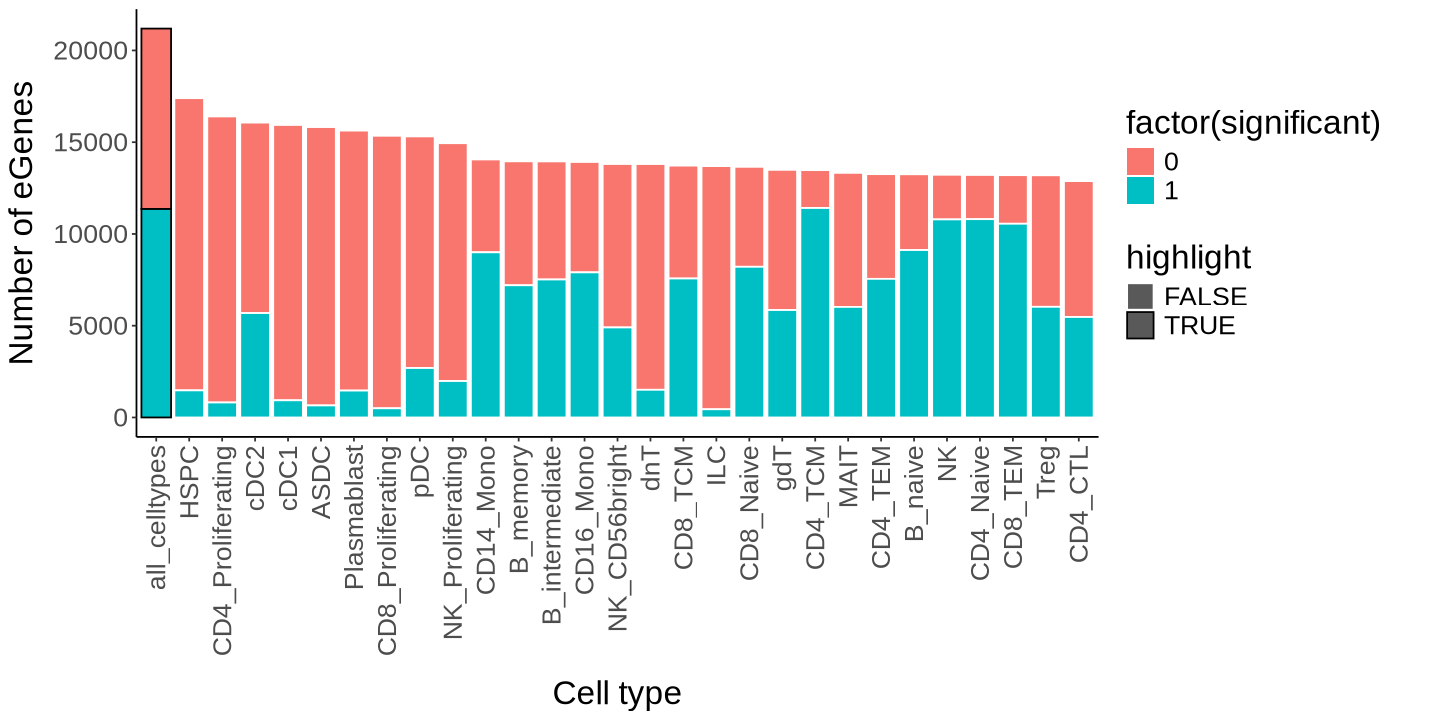

In [20]:
options(repr.plot.width = 12, repr.plot.height = 6)
p = ggplot(df_to_plot, aes(x=reorder(celltype,-n), y=n, fill=factor(significant))) 
p = p + geom_bar(stat='identity', aes(color = highlight)) 
p = p + scale_color_manual(values = c("TRUE" = "black", "FALSE" = "white")) 
p = p + theme_classic() 
p = p + theme(text = element_text(size=20), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
p = p + ylab('Number of eGenes') + xlab('Cell type')
p

In [21]:
df_combine = df_combine %>% mutate(p_1e_6 = ifelse(top_pval < 1e-6, 1, 0))

In [22]:
df_to_plot1 = as.data.frame(table(df_combine$celltype, df_combine$p_1e_6))
colnames(df_to_plot1) = c('celltype','p_1e_6','n')
head(df_to_plot1)

,celltype,p_1e_6,n
,<fct>,<fct>,<int>
1,all_celltypes,0,13851
2,ASDC,0,15393
3,B_intermediate,0,9609
4,B_memory,0,9758
5,B_naive,0,7480
6,CD14_Mono,0,8605


In [23]:
df_to_plot1 <- df_to_plot1 %>% mutate(highlight = ifelse(celltype == "all_celltypes", TRUE, FALSE))

In [24]:
# Create a new variable for ordering based on significant == 1
order_levels <- df_to_plot1 %>%
  filter(p_1e_6 == 1) %>%
  arrange(desc(n)) %>%
  pull(celltype)

# Set as factor with levels in desired order
df_to_plot1$celltype <- factor(df_to_plot1$celltype, levels = order_levels)

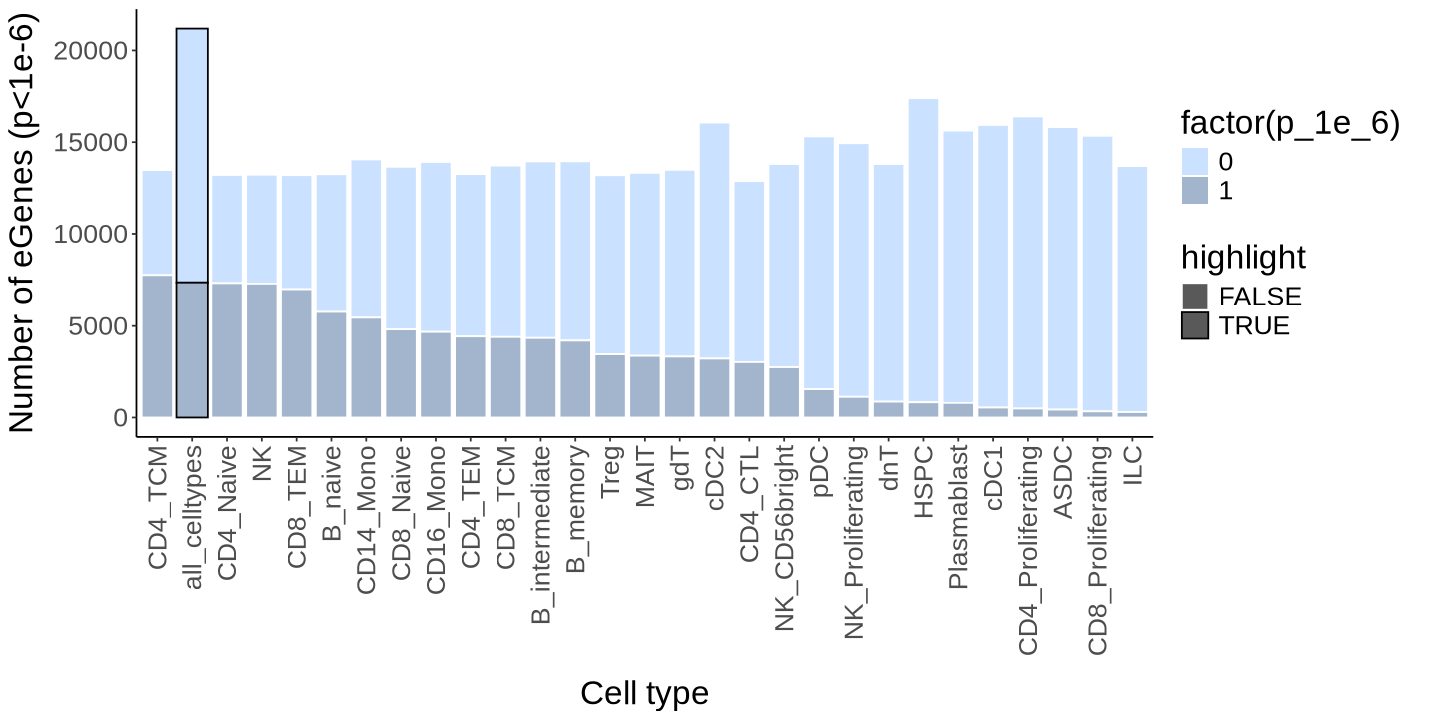

In [25]:
options(repr.plot.width = 12, repr.plot.height = 6)
p = ggplot(df_to_plot1, aes(x=celltype, y=n, fill=factor(p_1e_6))) 
p = p + geom_bar(stat='identity', aes(color = highlight)) 
p = p + scale_color_manual(values = c("TRUE" = "black", "FALSE" = "white"))
p = p + scale_fill_manual(values = c('lightsteelblue1','lightsteelblue3'))
p = p + theme_classic() 
p = p + theme(text = element_text(size=20), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
p = p + ylab('Number of eGenes (p<1e-6)') + xlab('Cell type')
p

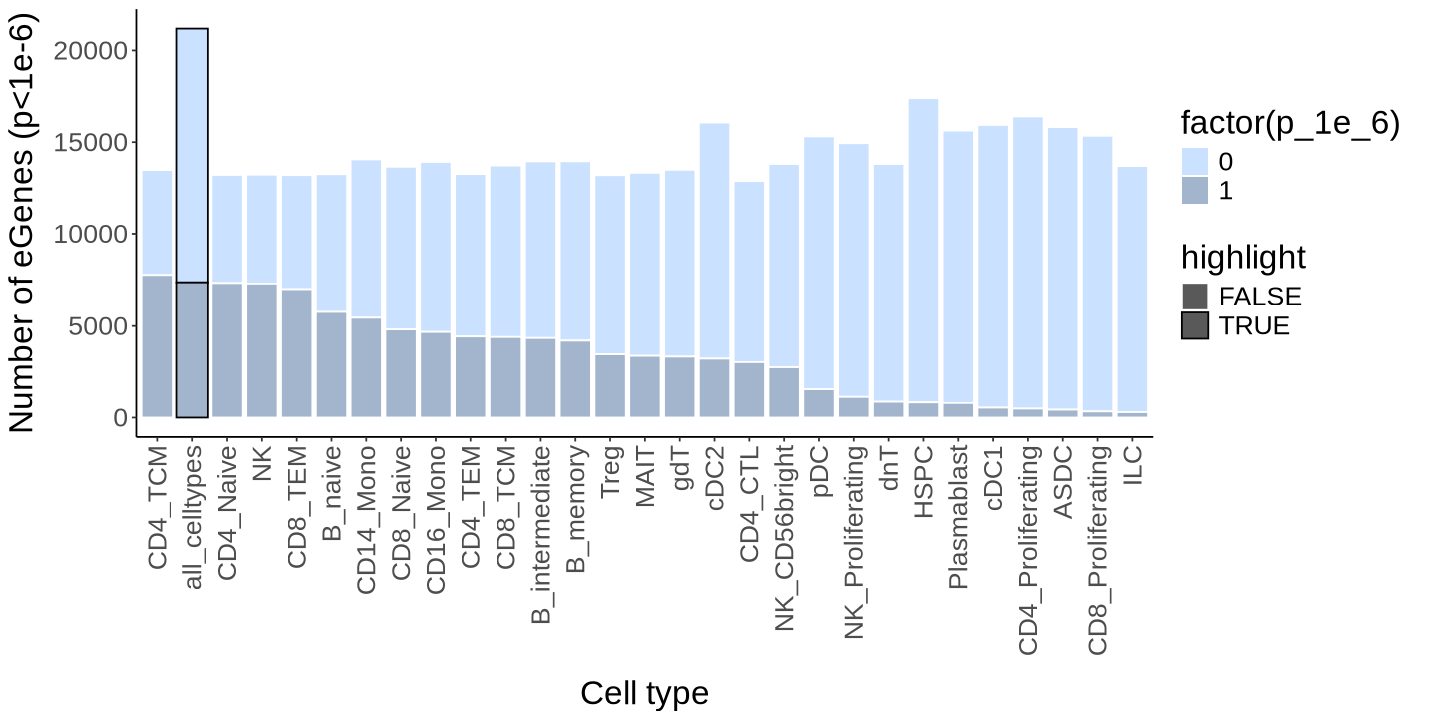

In [26]:
options(repr.plot.width = 12, repr.plot.height = 6)
p = ggplot(df_to_plot1, aes(x=celltype, y=n, fill=factor(p_1e_6))) 
p = p + geom_bar(stat='identity', aes(color = highlight)) 
p = p + scale_color_manual(values = c("TRUE" = "black", "FALSE" = "white"))
p = p + scale_fill_manual(values = c('lightsteelblue1','lightsteelblue3'))
# p = p + geom_bar(stat='identity', data=df_to_plot1[df_to_plot1$highlight=='TRUE',],fill=c('palevioletred3','palevioletred4'))
p = p + theme_classic() 
p = p + theme(text = element_text(size=20), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
p = p + ylab('Number of eGenes (p<1e-6)') + xlab('Cell type')
p

Warning message:
“Using alpha for a discrete variable is not advised.”


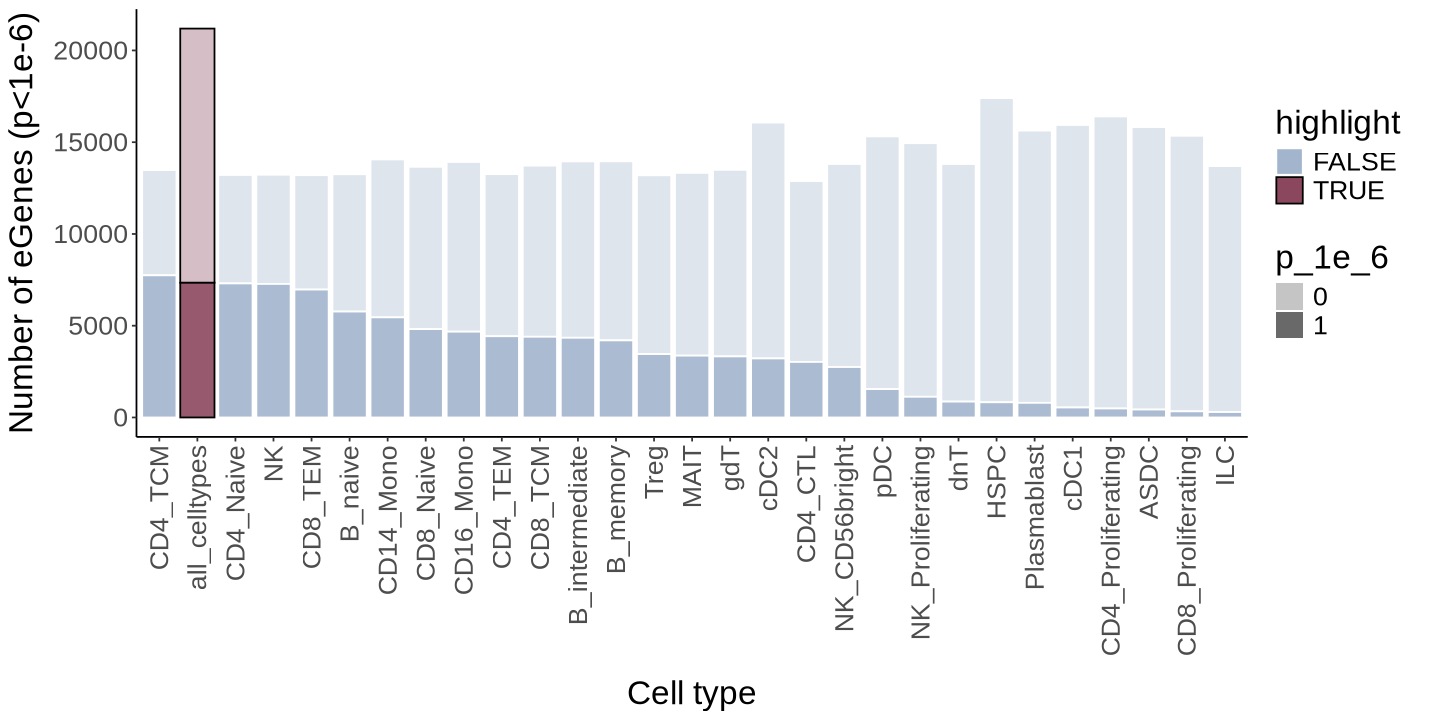

In [27]:
options(repr.plot.width = 12, repr.plot.height = 6)
p = ggplot(df_to_plot1, aes(x=celltype, y=n, alpha=p_1e_6)) 
p = p + geom_bar(stat='identity', aes(fill=highlight, colour=highlight)) 
p = p + scale_color_manual(values = c("TRUE" = "black", "FALSE" = "white"))
p = p + scale_fill_manual(values = c("TRUE" = 'palevioletred4',"FALSE" = 'lightsteelblue3'))
p = p + scale_alpha_discrete(range = c(0.35, 0.9))
p = p + theme_classic() 
p = p + theme(text = element_text(size=20), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
p = p + ylab('Number of eGenes (p<1e-6)') + xlab('Cell type')
p

In [28]:
head(df_combine)

,gene,ACAT_p,top_MarkerID,top_pval,qv,significant,celltype,p_1e_6
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,ENSG00000000457,0.2842556,1:169927679:G:GT,0.001991190,0.8117725,0,ASDC,0
2,ENSG00000000460,0.9486428,1:169788459:T:C,0.003823260,0.9977706,0,ASDC,0
3,ENSG00000000938,0.6203965,1:27697371:C:A,0.003466500,0.9977706,0,ASDC,0
4,ENSG00000001460,0.8674904,1:24322926:C:T,0.000183998,0.9977706,0,ASDC,0
5,ENSG00000001461,0.9658630,1:24374254:TTTG:T,0.006238500,0.9977706,0,ASDC,0
6,ENSG00000004455,0.9117075,1:32976533:A:ACACAC,0.004864050,0.9977706,0,ASDC,0


In [29]:
length(celltypes)

[1] 28

In [30]:
pb_egenes = unique(df_combine[df_combine$celltype == 'all_celltypes' & df_combine$top_pval < 1e-6,'gene'])
length(pb_egenes)
sc_egenes = c()
for (celltype in celltypes){
    ct_egenes = unique(df_combine[df_combine$celltype == celltype & df_combine$top_pval < 1e-6,'gene'])
    sc_egenes = unique(c(sc_egenes,ct_egenes))
}
length(sc_egenes)

[1] 7341

[1] 13569

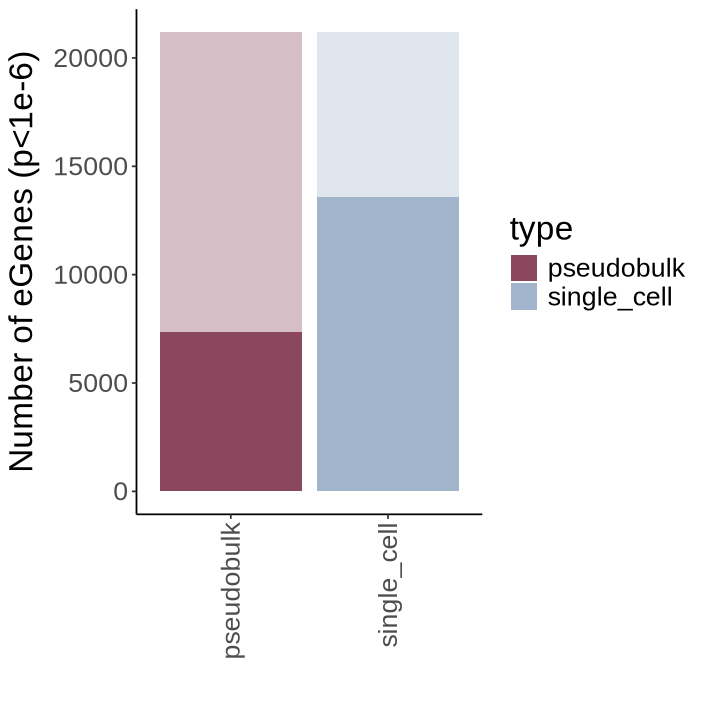

In [31]:
df_to_plot2 = data.frame(egenes = c(length(sc_egenes), length(pb_egenes)),
               type = c('single_cell','pseudobulk'),
               all_genes = length(unique(df_combine$gene)))
options(repr.plot.width = 6, repr.plot.height = 6)
p = ggplot(df_to_plot2, aes(x=type, y=all_genes, fill=type)) 
p = p + geom_bar(stat='identity',alpha=0.35) 
p = p + geom_bar(stat='identity',aes(x=type, y=egenes, fill=type)) 
p = p + scale_fill_manual(values = c('palevioletred4','lightsteelblue3')) 
p = p + theme_classic() 
p = p + theme(text = element_text(size=20), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
p = p + ylab('Number of eGenes (p<1e-6)') + xlab('')
p

In [32]:
pb_egenes = unique(df_combine[df_combine$celltype == 'all_celltypes' & df_combine$qv < 0.05,'gene'])
length(pb_egenes)
sc_egenes = c()
for (celltype in celltypes){
    ct_egenes = unique(df_combine[df_combine$celltype == celltype & df_combine$qv < 0.05,'gene'])
    sc_egenes = unique(c(sc_egenes,ct_egenes))
}
length(sc_egenes)

[1] 11359

[1] 17522

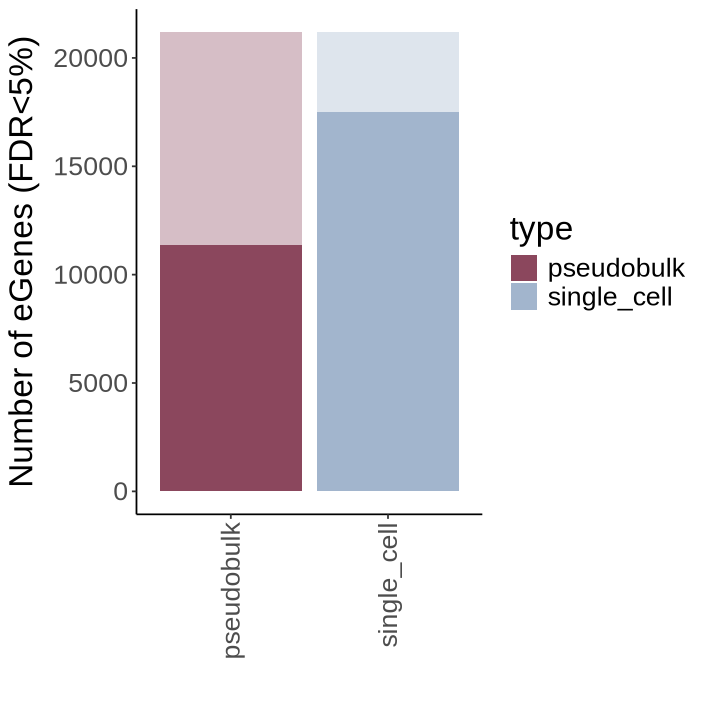

In [33]:
df_to_plot2 = data.frame(egenes = c(length(sc_egenes), length(pb_egenes)),
               type = c('single_cell','pseudobulk'),
               all_genes = length(unique(df_combine$gene)))
options(repr.plot.width = 6, repr.plot.height = 6)
p = ggplot(df_to_plot2, aes(x=type, y=all_genes, fill=type)) 
p = p + geom_bar(stat='identity',alpha=0.35) 
p = p + geom_bar(stat='identity',aes(x=type, y=egenes, fill=type)) 
p = p + scale_fill_manual(values = c('palevioletred4','lightsteelblue3'))  
p = p + theme_classic() 
p = p + theme(text = element_text(size=20), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
p = p + ylab('Number of eGenes (FDR<5%)') + xlab('')
p